In [1]:
import numpy as np 
import matplotlib.pyplot as plt



In [2]:
def f(x):
    return x**2

def df(x):
    return 2 * x


Step  1 | x = 4.000000 | f(x) = 16.000000 | slope = 10.000000
Step  2 | x = 3.200000 | f(x) = 10.240000 | slope = 8.000000
Step  3 | x = 2.560000 | f(x) = 6.553600 | slope = 6.400000
Step  4 | x = 2.048000 | f(x) = 4.194304 | slope = 5.120000
Step  5 | x = 1.638400 | f(x) = 2.684355 | slope = 4.096000
Step  6 | x = 1.310720 | f(x) = 1.717987 | slope = 3.276800
Step  7 | x = 1.048576 | f(x) = 1.099512 | slope = 2.621440
Step  8 | x = 0.838861 | f(x) = 0.703687 | slope = 2.097152
Step  9 | x = 0.671089 | f(x) = 0.450360 | slope = 1.677722
Step 10 | x = 0.536871 | f(x) = 0.288230 | slope = 1.342177
Step 11 | x = 0.429497 | f(x) = 0.184467 | slope = 1.073742
Step 12 | x = 0.343597 | f(x) = 0.118059 | slope = 0.858993
Step 13 | x = 0.274878 | f(x) = 0.075558 | slope = 0.687195
Step 14 | x = 0.219902 | f(x) = 0.048357 | slope = 0.549756
Step 15 | x = 0.175922 | f(x) = 0.030949 | slope = 0.439805
Step 16 | x = 0.140737 | f(x) = 0.019807 | slope = 0.351844
Step 17 | x = 0.112590 | f(x) = 0.012

C:\Users\annat\AppData\Local\Temp\ipykernel_16616\1110361759.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


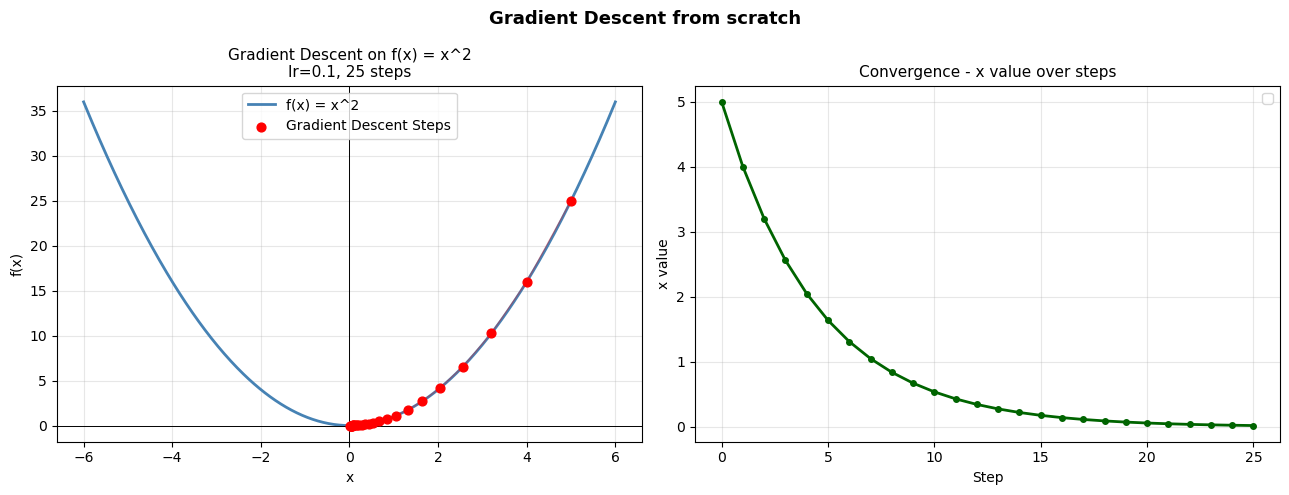

In [3]:
learning_rate = 0.1
x = 5
steps = 25

x_history = [x]

for i in range(steps):
    slope = df(x)
    x = x - learning_rate * slope
    x_history.append(x)
    print(f"Step {i+1:2d} | x = {x:.6f} | f(x) = {f(x):.6f} | slope = {slope:.6f}")


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#left plot f(x) curve 
x_range = np.linspace(-6, 6, 500)
ax = axes[0]
ax.plot(x_range, f(x_range),color='steelblue', linewidth=2, label="f(x) = x^2")

#plot points 
history_arr = np.array(x_history)   
ax.scatter(history_arr, f(history_arr), color='red', zorder=5, s=40, label="Gradient Descent Steps")

#connect the dots
ax.plot(history_arr, f(history_arr), color='red', alpha=0.3, linewidth=1)

ax.axhline(y=0, color='black', linewidth=0.7)
ax.axvline(x=0, color='black', linewidth=0.7)
ax.set_title(f"Gradient Descent on f(x) = x^2\nlr={learning_rate}, {steps} steps", fontsize=11)
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.legend()
ax.grid(True, alpha=0.3)

#right plot x value over time (convergance plot)
ax2 = axes[1]
ax2.plot(range(len(x_history)), x_history, color='darkgreen',linewidth=2, marker='o', markersize=4)
ax2.set_title("Convergence - x value over steps", fontsize=11)
ax2.set_xlabel("Step")
ax2.set_ylabel("x value")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Gradient Descent from scratch", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

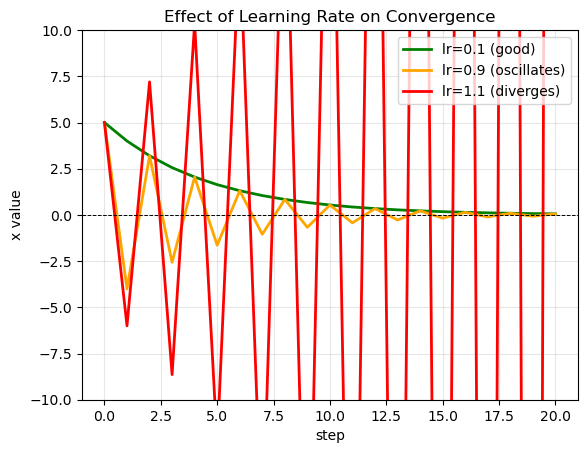

In [4]:

for lr, color, label in [(0.1, 'green', 'lr=0.1 (good)'), 
                          (0.9, 'orange', 'lr=0.9 (oscillates)'), 
                          (1.1, 'red', 'lr=1.1 (diverges)')]:
    x = 5.0
    hist = [x]
    for _ in range(20):
        x = x - lr * df(x)
        hist.append(x)
    plt.plot(range(len(hist)), hist, color=color, label=label, linewidth=2)

plt.axhline(y=0, color='black', linewidth=0.7, linestyle='--')
plt.title("Effect of Learning Rate on Convergence", fontsize=12)
plt.xlabel("step")
plt.ylabel("x value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-10, 10)
plt.show()